# Name: Shamir Maharjan
# Student ID: 2417731

# 2. Introduction to Keras.

Keras is a high-level API for building and training deep learning models. It runs on top of other
deep learning frameworks such as TensorFlow, Theano, and CNTK, and provides a simple interface for
designing complex neural networks.

In [2]:
import keras
import tensorflow as tf

print(f"Keras: {keras.__version__}")
print(f"TensorFlow: {tf.__version__}")

Keras: 3.13.2
TensorFlow: 2.21.0


## 2.1 Why not Just Use Numpy?

### 1. NumPy Lacks Automatic Differentiation:

Neural Networks rely on backpropagation to compute gradients for optimization. Numpy does not
support automatic differentiation.

Manual Gradient Calculation in Numpy

In [3]:
import numpy as np
# Simple function f(x) = x^2
def f(x):
    return x ** 2
# Manual derivative (f’(x) = 2x)
def gradient(x):
    return 2 * x
# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # Manually optimize for 10 steps
    x -= learning_rate * gradient(x)
    print(f"x: {x}, f(x): {f(x)}")

x: 4.0, f(x): 16.0
x: 3.2, f(x): 10.240000000000002
x: 2.56, f(x): 6.5536
x: 2.048, f(x): 4.194304
x: 1.6384, f(x): 2.68435456
x: 1.31072, f(x): 1.7179869184000003
x: 1.0485760000000002, f(x): 1.0995116277760004
x: 0.8388608000000002, f(x): 0.7036874417766403
x: 0.6710886400000001, f(x): 0.45035996273704976
x: 0.5368709120000001, f(x): 0.2882303761517119


Gradient Computations with Keras.

In [4]:
import tensorflow as tf
x = tf.Variable(5.0) # Trainable variable
with tf.GradientTape() as tape:
    y = x ** 2 # y = x^2
    grad = tape.gradient(y, x) # Computes dy/dx automatically
    print(grad.numpy()) # Output: 10.0

10.0


### 2. Numpy is Slow for Large Models:

Numpy runs only on CPU and does not support GPU acceleration.

• Deep Learning requires millions of matrix operations, which Numpy alone can not optimize effi-
ciently.

Example: Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU).

In [5]:
import numpy as np
import tensorflow as tf
import time
# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)
# NumPy Multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)
# TensorFlow Multiplication (for colab uses GPU Runtime if available)
A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.05063819885253906
TensorFlow Time: 0.05983567237854004


### 3. No Pre-built Activation Functions and Layers in NumPy.

In deep learning, we use functions like:

• sigmoid:

• Softmax:

With Numpy we’d have to manually implement every function. In keras it already has built it.

Implementation of Activation Function with Keras.

In [6]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import sigmoid

layer = Dense(64, activation=sigmoid)

Dense: This specifies the type of layer. In a Dense layer, every neuron is connected to every single neuron in the previous layer
.
64 (units): This argument defines the number of neurons (or nodes) that will exist within this specific layer
.
activation='sigmoid': This defines the mathematical function applied to the output of each neuron
. The sigmoid function (f(x)= 
1+e 
−x
 
It is used to squash the output values, often used in binary classification or hidden layers

### 4. Keras supports Model Training, Numpy Does not:

Once your model is built, training it in Numpy is complex:

• Compute forward pass.

• Compute loss.

• Compute backward pass manually.

• Update weights using gradients.

Manually Training Network in Numpy.

• ✗ Difficult to debug.

• ✗ Does not scale well.

• ✗ No automatic gradient computation.

keras training is One Line.

x_train: This is the input training data (the features, such as image pixel values) that the model will learn from
.

y_train: These are the target labels (the correct answers) that correspond to the input data
.

epochs=10: This defines the number of times the entire training dataset is passed through the model

. In this case, the model will iterate over all your training data 10 times.

batch_size=32: This specifies the number of training samples the model processes before updating its internal weights

. Instead of looking at every image at once, it looks at a "batch" of 32, calculates the error, and adjusts itself before moving to the next batch
.

What happens during this process?

Learning: The model uses an optimizer (defined during compilation) to adjust its learnable parameters (weights and biases) to minimize the difference between its predictions and the actual labels

.
Automation: Unlike NumPy, where you must manually compute gradients and update weights, Keras handles this "Easy and Efficiently" in the background
.

Tracking: The function returns a History object, which contains a record of the training loss and accuracy metrics for each of the 10 epochs

. This data can later be used to visualize how well the model learned over time

### 5. No Prebuilt Layers in Numpy:

In keras, we can easily define layers like:

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.activations import relu, softmax

model = Sequential([
    Input(shape=(784,)),            # Define the input shape first
    Dense(64, activation=relu),      # hidden layer 
    Dense(10, activation=softmax)    # output layer
])

### 6. No prebuilt Optimizers in NumPy:
Deep learning requires optimization algorithms like:

• SGD (Stochastic Gradient Descent) or Mini - Batch Gradient Descent.
    
• Adam (Adaptive Momentum Estimation)

Implementing SGD in Numpy.

In [8]:
learning_rate = 0.01
weights = np.random.randn(3, 3)
for _ in range(100): # Training loop
    gradient = np.random.randn(3, 3) # Fake gradient for illustration
    weights -= learning_rate * gradient

✓Works, but hard to scale for complex models.

In Keras.

In [9]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

### Lesson Learned:

• Can you build a neural network with NumPy? Yes!

• Should you?

– Not if you want efficiency, scalability, and easy debugging!

## 3 Understanding Fully Connected Layers.

A fully connected (dense) layer means that every input node is connected to every node in the next
layer. This is a fundamental building block of neural networks. In Keras, this is implemented using the
Dense class.

### 1. Dense Class in Keras:

The Dense lass in keras is used to create a fully connected layers also called dense layers in a
neural network. Each neuron in a Dense layer is connected to every neuron in the previous layer.

Argument Description

units = Number of neurons in the layer.

activation = Activation function applied to the neurons. Default: None (linear activation).

use bias = Whether to include a bias term. Default: True.

kernel initializer = Method to initialize the weights. Default: "glorot uniform".

bias initializer = Method to initialize the bias. Default: "zeros".

kernel regularizer=  Regularization applied to the weights (e.g., L1, L2).

bias regularizer = Regularization applied to the bias.

### 2. How Does Dense Work ?
Each neuron in a Dense layer computes:

y = activation(W x + b) (1)

where:

• x = Input data (vector or matrix).

• W = Weights matrix (learnable parameters).

• b = Bias term (optional).

• activation = Activation function applied to the output.

### Some Common Activation Function:

Activation Function

ReLU (relu) f(x) = max(0, x) (Good for hidden layers)

Sigmoid (sigmoid) f(x) = 1/1+e−x (Used for binary classification)

Softmax (softmax) = Converts output into probabilities (Used for multi-class
classification)

Tanh (tanh) f(x) = e
x−e−x/
e
x+e−x (Outputs values between -1 and 1)

### 4 Building a Simple Fully Connected Neural Network in Keras.

In this section, we will build a general pipeline for solving an image classification problem using a fully
connected neural network in Keras. This pipeline will largely remain the same for future implementations
of more complex models for image classification.

### 1. Load and Preprocess the Data:

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


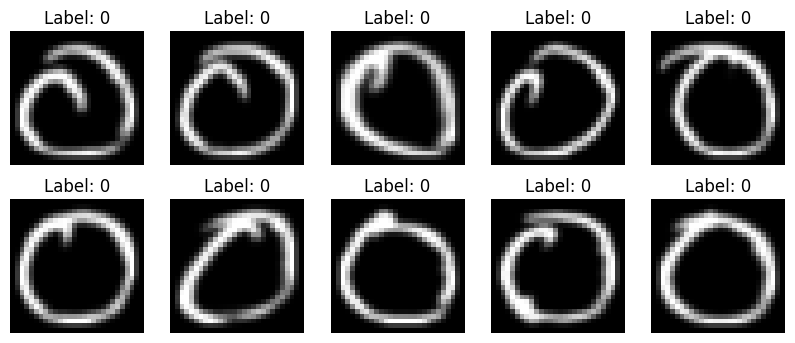

In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\Workshop 4\\DevanagariHandwrittenDigitDataset\\Train"
test_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\Workshop 4\\DevanagariHandwrittenDigitDataset\\Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            # Load image using PIL
            img = Image.open(img_path).convert("L") # Convert to grayscale
            img = img.resize((img_width, img_height)) # Resize to (28,28)
            img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
            images.append(img)
            labels.append(label)
            
    return np.array(images), np.array(labels)


# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)

x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.show()

### The Images Compatible with Keras:

In keras, the input to the model must follow a specific shape. For image data, the expected input shape
typically looks like:

• Grayscale Image: (num samples, height, width, 1)

• RGB Image: (num samples, height, width, 3)

In our case, we are working with grayscale images and resizing them to
(num samples, 28 × 28, 1)

This shape means that:

• num samples: Number of images in the dataset.
    
• 28, 28: Height and Width of the image.
    
• 1: Number of channels (since grayscale images have only one channel, representing gray scale
intensity.)

Reshaping for Keras compatibility:


In [11]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_train.shape

(17000, 28, 28, 1)

## 2. Build the Model:

Keras provides two ways to build models: Sequential API and Functional API. Both approaches
allow you to create neural networks, but the choice between them depends on the complexity and
flexibility of the model you want to create.

### 1. Sequential API:
The Sequential API is the simplest and most straightforward way to define a model in Keras. It is used
when your model consists of a linear stack of layers. Each layer has one input tensor and one output
tensor, making it ideal for simple, layer-by-layer models.

##### Rule: Data flows in one direction (Linear). No branching, no loops.

In [12]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## 2. Functional API:
The Functional API is a more flexible way to define models. It allows you to define complex models with
multiple inputs, outputs, shared layers, or even non-linear topologies (such as multi-branch networks).
You have more control over the architecture and can define layers that may not be directly connected.

In [3]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
def build_functional_model():
    # Input layer
    inputs = keras.Input(shape=input_shape)
    # Flatten layer
    x = keras.layers.Flatten()(inputs)
    # Hidden layers
    x = keras.layers.Dense(64, activation="sigmoid")(x)
    x = keras.layers.Dense(128, activation="sigmoid")(x)
    x = keras.layers.Dense(256, activation="sigmoid")(x)
    # Output layer
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model
# Build the model
functional_model = build_functional_model()
functional_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Compiling and Training the Model:

After defining a model using either the Sequential API or Functional API, we need to compile and train
it before making predictions.
    
1. Compilation:

Compilation prepares the model for training by specifying:

• Loss function: Measures how well the model performs (e.g., categorical crossentropy for multi-
class classification).

• Optimizer: Updates the model parameters to minimize loss (e.g., adam).
                              
• Metrics: Monitors performance (e.g., accuracy).

The model.compile() function in keras is used to configure the model training by specifying the opti-
mizer, loss function and evaluation metrics.

Parameter Description Example Values

optimizer = Specifies the optimization algorithm used to update weights. = "sgd", "adam", etc

loss = Defines the loss function that measures model performance. = "categorical crossentropy","sparse categorical crossentropy","binary crossentropy"

metrics = Specifies evaluation metrics to monitor during training. = ["accuracy"], ["precision", "recall"], ["mae"]

In [24]:
model.compile(
optimizer="adam", # Stochastic Gradient Descent
loss="categorical_crossentropy", # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

##### Some Common Loss function used for Classification Task in Keras:
    
Loss Function             Description           When to Use?
categorical crossentropy  = Computes the cross-entropy loss for multi-class classification with one-hot encoded labels. = Multi-class classification (e.g., MNIST with 10 dig-
its).

sparse categorical crossentropy  = Similar to categorical cross-entropybut expects labels as integers insteadof one-hot encoded vectors. = When labels are integers(e.g., 0,1,2,...,9) instead of
one-hot encoding.

binary crossentropy = Computes the loss for binary classification problems. = When there are only two
possible classes (e.g., cat vs.
dog).

mean squared error (MSE) =  Measures the squared difference be-tween actual and predicted values. = Rarely used in classifica-
tion; mainly for regression tasks.

##### Some Common Optimizers used for training of FCN:
Optimizer Description When to Use?

adam  = Combines the advantages of Adagrad and RMSprop. It adjusts the learning rate dynamically and works well for a wide range of tasks. =  General purpose optimizer; works well for
most image classification tasks.

sgd =  Stochastic Gradient Descent. It updates parameters by calculating the gradient on each training example (or a mini-batch). = When you need fine control over learning
rate or when training large datasets.

rmsprop =  Divides the learning rate by an exponen-
tially decaying average of squared gradi-
ents. It works well for non-stationary ob-
jectives. =  Suitable for problems with noisy or sparse
gradients, like RNNs.

adagrad  = Adapts the learning rate based on how
frequently each parameter is updated. It
works well for sparse data. = Works well with sparse data, such as natu-
ral language processing or computer vision
tasks with sparse features.

adadelta  =  An extension of Adagrad that seeks to
solve its diminishing learning rate prob-
lem by limiting the accumulated past gra-
dients. = When you want to address the decreasing
learning rate problem in Adagrad.

## 2. Training of the Model:

Once the model are compiled, keras uses fit() function to train the model. It takes the training data
and trains the model for a fixed number of epochs (iterations over the entire dataset.)

Example Code for fit()

In [26]:
batch_size = 128
epochs = 20
# Callbacks
callbacks = [
keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
# Train the model with callbacks and validation split
history = model.fit(
x_train,
y_train,
batch_size=batch_size,
epochs=epochs,
# validation_split=0.2,
    validation_data = (x_test, y_test),
callbacks=callbacks,
verbose = 1
)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9039 - loss: 0.4963 - val_accuracy: 0.9467 - val_loss: 0.1986
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9667 - loss: 0.1225 - val_accuracy: 0.9633 - val_loss: 0.1345
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9774 - loss: 0.0832 - val_accuracy: 0.9703 - val_loss: 0.1132
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9849 - loss: 0.0609 - val_accuracy: 0.9700 - val_loss: 0.1049
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9881 - loss: 0.0489 - val_accuracy: 0.9710 - val_loss: 0.0962
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9912 - loss: 0.0388 - val_accuracy: 0.9753 - val_loss: 0.0876
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9935 - loss: 0.0317 - val_accuracy: 0.9763 - val_loss: 0.0867
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9948 - loss: 0.0253 - val_accuracy: 0.

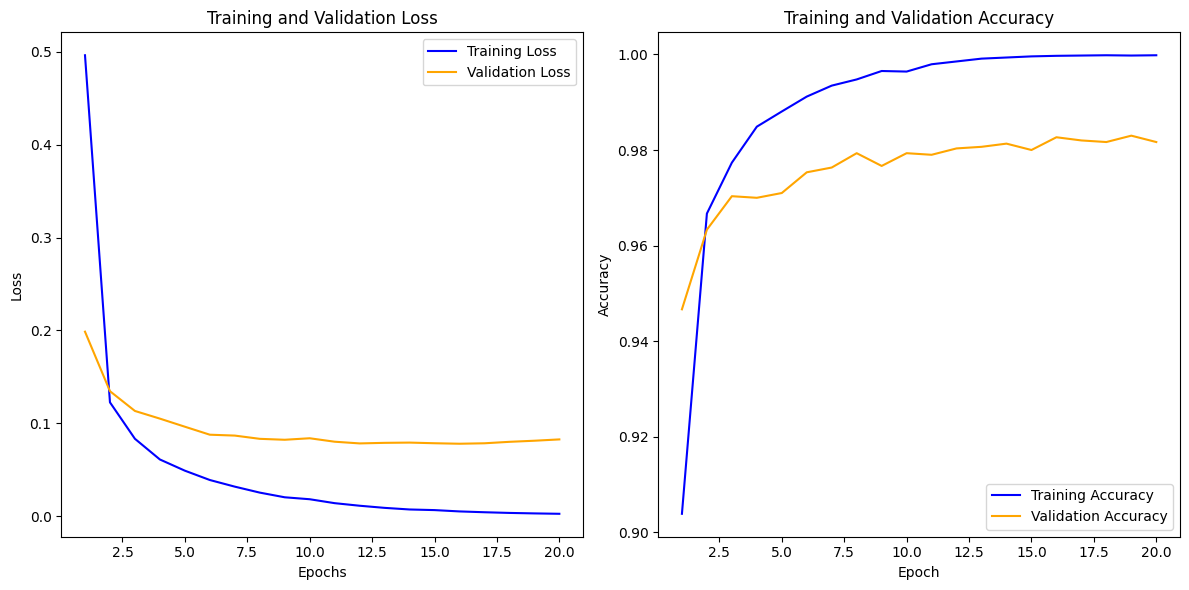

In [34]:
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel("Epoch")
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
history.history

{'accuracy': [0.9038823246955872,
  0.966705858707428,
  0.9773529171943665,
  0.9848823547363281,
  0.9880588054656982,
  0.9911764860153198,
  0.9934706091880798,
  0.9947646856307983,
  0.9965294003486633,
  0.9964117407798767,
  0.9979411959648132,
  0.9985294342041016,
  0.9991176724433899,
  0.9993529319763184,
  0.9995882511138916,
  0.9997059106826782,
  0.9997646808624268,
  0.9998235106468201,
  0.9997646808624268,
  0.9998235106468201],
 'loss': [0.49633604288101196,
  0.12248647212982178,
  0.08322645723819733,
  0.06094563007354736,
  0.04888428375124931,
  0.0388299934566021,
  0.031682662665843964,
  0.025260454043745995,
  0.020219260826706886,
  0.01812124066054821,
  0.013889833353459835,
  0.01112178061157465,
  0.00882633775472641,
  0.007094434462487698,
  0.0064186095260083675,
  0.004998988937586546,
  0.004111106041818857,
  0.0033784417901188135,
  0.0028586515691131353,
  0.0024388853926211596],
 'val_accuracy': [0.9466666579246521,
  0.9633333086967468,
  0.9

The history.history attribute contains the loss and accuracy values for both the training and valida-
tion sets.

• train loss, val loss, train acc, and val acc: These variables are extracted from the history
object, which stores the progress of training.

The code creates two plots:

• Training and Validation Loss: Shows how the loss decreases (or increases) over epochs.
    
• Training and Validation Accuracy: Shows how the accuracy improves over epochs.
    
Both plots are displayed side by side using subplots. This visualization helps in understanding the
model’s learning curve, including whether it is overfitting, underfitting, or generalizing well.

## 4. Evaluate the Model:

The model.evaluate() function in Keras is used to evaluate the model’s performance on a test dataset
(or validation dataset). It returns the loss value and the metric(s) specified during the model.compile()
phase, which can help assess how well the model generalizes to new, unseen data.

##### Syntax for model.evaluate()

model.evaluate(x=None, y=None, batch_size=None, verbose=1, sample_weight=None, steps=None, callbacks
=None, max_queue_size=10, workers=1, use_multiprocessing=False)

x = The input data on which the model will
be evaluated. Can be a Numpy array,
Tensor, or a dataset object. = x test

y = The true labels for the input data. Can
be one-hot encoded or integer labels,
depending on the loss function. = y test

batch size = Number of samples per evaluation
batch. If None, the default batch size
of 32 is used. = 64, 128

verbose = Controls the verbosity of the evaluation process. = 0 (Silent), 1 (Progress
bar), 2 (One line per
epoch)

sample_weight = Weights for each sample during evalu-
ation. If None, each sample is given
equal weight. = weights array

steps = The number of steps (batches) to run
for evaluation when using a generator.
If None, the entire dataset is used. = 100, 200

callbacks = List of Keras callbacks to apply during
evaluation. = [callback 1,
callback 2]

max_queue_size = Maximum size of the generator queue
for evaluation. = 10 (default)

workers = Number of workers for loading data in
the background. = 
1, 4

use_multiprocessing = Whether to use the multiprocessing
start method for parallel data loading.
=  False (default)

##### The model.evaluate Returns following:

• loss: The loss value, as defined by the loss function.

• metrics: The value(s) of the metrics specified during model.compile().

In [39]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1, batch_size=64) # default 32 batch
print(f"Test accuracy: {test_acc:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9817 - loss: 0.0826   
Test accuracy: 0.9817


## 5. Making Predictions with Keras:

Once the model is trained, you can use it to make predictions on new data using model.predict() function
of keras:

In [41]:
# Predict on test data
predictions = model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 0
True label for first image: 0


##### Explanation of model.predict() and Predicted Labels

• predictions = model.predict(x test): This line uses the trained model to make predictions on
the test data (x test). 

The predict() function returns a Numpy array of predicted probabilities
for each class. In a multi-class classification task, this will return a probability distribution over
the classes for each test sample.
    
Next, we convert these probabilities into class labels:
    
• predicted labels = np.argmax(predictions, axis=1): This line extracts the predicted class
labels by selecting the class with the highest probability. The np.argmax() function returns the
index of the maximum value along the specified axis (axis=1 refers to the class dimension).

The following print statements display the predicted and true labels for the first image in the test
set:

• print(f”Predicted label for first image: predicted labels[0]”): This prints the predicted
label for the first image in the test set.

• print(f”True label for first image: np.argmax(y test[0])”): This prints the true label for
the first image, where np.argmax(y test[0]) extracts the index of the correct class from the
one-hot encoded vector in y test.

The predicted label corresponds to the class with the highest predicted probability, while the true
label corresponds to the actual class. Comparing these values allows us to check how well the model is
performing on individual test samples.

## 6. Saving and Loading the Model:

### 1. Saving the Model:

In [43]:
model.save('mnist_fully_connected_model.keras')

model.save(): This function saves the entire model (including architecture, weights, and opti-
mizer state) to a specified file.

• mnist fully connected model.keras: This is the filename where the model will be saved. The
model will be stored in the current working directory.

### 2. Loading the Model:

In [45]:
loaded_model = tf.keras.models.load_model('C:\\Users\\LOQ\\semester 6\\AIML\\Workshop 4\\mnist_fully_connected_model.keras')

In [46]:
print(loaded_model)

<Sequential name=sequential_1, built=True>
